Nacitanie a prichystanie dat podla fazy 1

In [61]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer


In [62]:
top10Attributes = ["PI", "Motion/Activity index", "Signal Quality Index", "Skin Temperature", "EtCO₂", "RR", "PRV", "BP", "SV", "FiO₂"]
RANDOM_STATE = 123

df_observation = pd.read_csv('datasets/observation.csv',sep='\t')

def getOutliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)

    return (a > upper) | (a < lower)

def cleanOutliers(data, cols):
    for c in cols:
        mask = getOutliers(data[c])

        below = data[c].quantile(0.05)
        above = data[c].quantile(0.95)

        for i in data.index[mask]:
            value = data.at[i, c]

            if value < below:
                data.at[i, c] = below
            elif value > above:
                data.at[i, c] = above

def histogramiada(df, columns, bins=30):

    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    axes = axes.flatten()

    for i, col in enumerate(columns[:9]):
        sns.histplot(df[col], bins=bins, kde=True, ax=axes[i], color=sns.color_palette("tab10")[i % 10])
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    plt.tight_layout()
    plt.show()



# 2.1 Realizácia predspracovania dát

(A-1b) Dáta si rozdeľte na trénovaciu a testovaciu množinu podľa vami preddefinovaného pomeru. Ďalej pracujte len s trénovacím datasetom

In [63]:
df_train, df_test = train_test_split(df_observation, test_size=0.2, random_state=RANDOM_STATE)
print(df_train.shape,df_test.shape)

(9637, 23) (2410, 23)


(B-1b) Transformujte dáta na vhodný formát pre strojové učenie t.j. jedno pozorovanie musí byť opísané jedným riadkom a každý atribút musí byť v numerickom formáte. Iteratívne integrujte aj kroky v predspracovaní dát z prvej fázy ako celok.

C:\Users\adamp\AppData\Local\Temp\ipykernel_25172\4223086501.py:37: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\adamp\Skola\ZS3\IAU\Projekt\IAU-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


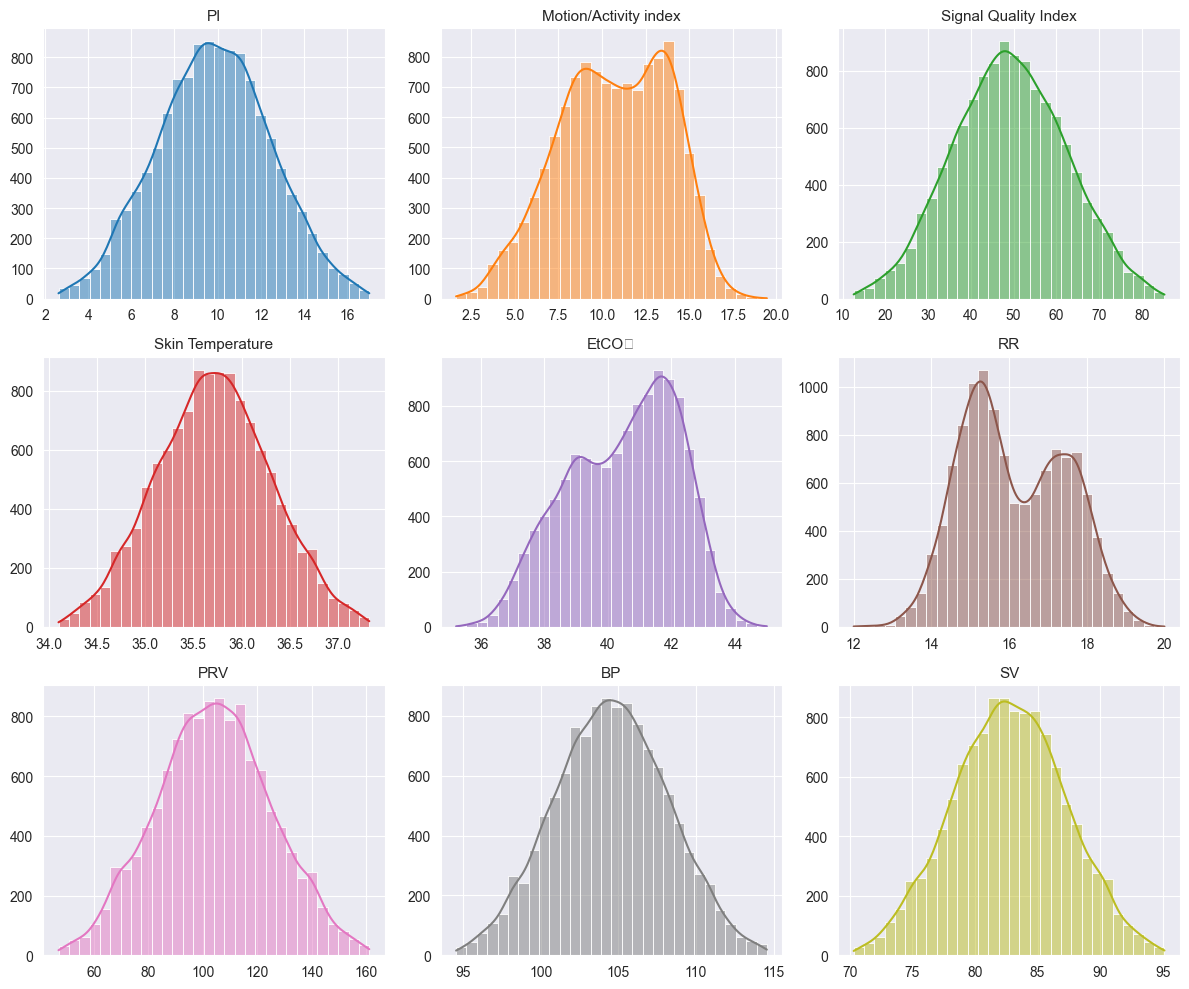

<class 'pandas.core.frame.DataFrame'>
Index: 9637 entries, 9547 to 3582
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PI                     9637 non-null   float64
 1   Motion/Activity index  9637 non-null   float64
 2   Signal Quality Index   9637 non-null   float64
 3   Skin Temperature       9637 non-null   float64
 4   EtCO₂                  9637 non-null   float64
 5   RR                     9637 non-null   float64
 6   PRV                    9637 non-null   float64
 7   BP                     9637 non-null   float64
 8   SV                     9637 non-null   float64
 9   FiO₂                   9637 non-null   float64
 10  oximetry               9637 non-null   float64
dtypes: float64(11)
memory usage: 903.5 KB


In [64]:
cleanOutliers(df_observation, top10Attributes)
histogramiada(df_observation, top10Attributes)

top10Attributes.append("oximetry")
df_train = df_train[top10Attributes]
df_train.info()

(C-1b) Transformujte atribúty dát pre strojové učenie podľa dostupných techník minimálne: scaling (2 techniky), transformers (2 techniky) a ďalšie. Cieľom je aby ste testovali efekty a vhodne kombinovali v dátovom pipeline (od časti 2.3 a v 3. fáze).

In [65]:
from scipy import stats
import pandas as pd

def CheckNormality(df, alpha=0.05):
    results = []

    for col in df.columns:
        if col == 'oximetry':
            continue

        data = df[col]

        # D'Agostino-Pearson Test
        stat, p = stats.normaltest(data)

        results.append({
            "column": col,
            "p_value": p,
            "is_normal": p > alpha
        })

    return pd.DataFrame(results)

normality_report = CheckNormality(df_train)
print(normality_report)


                  column        p_value  is_normal
0                     PI   9.051471e-01       True
1  Motion/Activity index  4.753921e-111      False
2   Signal Quality Index   5.848702e-01       True
3       Skin Temperature   4.191387e-01       True
4                  EtCO₂  3.207889e-154      False
5                     RR  8.564726e-306      False
6                    PRV   5.084350e-02       True
7                     BP   5.569837e-01       True
8                     SV   5.373238e-01       True
9                   FiO₂   1.393851e-02      False


In [67]:
scaler_std = StandardScaler()
scaled_std = scaler_std.fit_transform(df_train)

df_scaled_std = pd.DataFrame(scaled_std, columns=df_train.columns, index=df_train.index)
df_scaled_std.describe()

,PI,Motion/Activity index,Signal Quality Index,Skin Temperature,EtCO₂,RR,PRV,BP,SV,FiO₂,oximetry
count,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03
mean,-1.400883e-17,1.334526e-16,-2.123444e-16,1.587201e-14,7.173997e-16,7.181370e-16,1.607329e-16,-1.862437e-15,2.307771e-16,-1.411943e-16,3.133555e-17
std,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00
min,-3.575217e+00,-3.268448e+00,-3.665132e+00,-4.507217e+00,-3.170428e+00,-3.076116e+00,-3.863295e+00,-3.515011e+00,-4.940293e+00,-3.898849e+00,-1.204798e+00
25%,-6.730157e-01,-7.327692e-01,-6.754505e-01,-6.607025e-01,-7.784638e-01,-7.933399e-01,-6.595573e-01,-6.774274e-01,-6.763682e-01,-6.694466e-01,-1.204798e+00
50%,2.230352e-03,3.077499e-02,-6.255361e-03,-4.549152e-03,1.299598e-01,-1.544083e-01,-1.106840e-03,-8.960114e-04,-3.400197e-03,-1.906087e-02,8.300144e-01
75%,6.669125e-01,8.230506e-01,6.793021e-01,6.651390e-01,7.915629e-01,8.591928e-01,6.535227e-01,6.732947e-01,6.771557e-01,6.666779e-01,8.300144e-01
max,3.772848e+00,2.556769e+00,3.630626e+00,3.743537e+00,2.604836e+00,2.880895e+00,3.609345e+00,4.178718e+00,3.757198e+00,4.778137e+00,8.300144e-01


In [68]:
scaler_minmax = MinMaxScaler()
scaled_minmax = scaler_minmax.fit_transform(df_train)

df_scaled_minmax = pd.DataFrame(scaled_minmax, columns=df_train.columns, index=df_train.index)
df_scaled_minmax.describe()

,PI,Motion/Activity index,Signal Quality Index,Skin Temperature,EtCO₂,RR,PRV,BP,SV,FiO₂,oximetry
count,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000
mean,0.486552,0.561086,0.502365,0.546279,0.548967,0.516386,0.516992,0.456867,0.568014,0.449332,0.592093
std,0.136097,0.171676,0.137073,0.121207,0.173161,0.167878,0.133828,0.129983,0.114982,0.115253,0.491471
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.394961,0.435293,0.409784,0.466202,0.414174,0.383208,0.428729,0.368818,0.490248,0.372180,0.000000
50%,0.486856,0.566369,0.501507,0.545728,0.571470,0.490465,0.516844,0.456751,0.567623,0.447135,1.000000
75%,0.577312,0.702377,0.595474,0.626895,0.686028,0.660618,0.604447,0.544379,0.645870,0.526165,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [69]:
power = PowerTransformer(method='yeo-johnson', standardize=True)
trans_power = power.fit_transform(df_train)

df_trans_power = pd.DataFrame(trans_power, columns=df_train.columns, index=df_train.index)
df_trans_power.describe()

,PI,Motion/Activity index,Signal Quality Index,Skin Temperature,EtCO₂,RR,PRV,BP,SV,FiO₂,oximetry
count,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03,9.637000e+03
mean,-1.194437e-16,-1.185221e-16,-7.225608e-17,-1.413417e-15,-8.832938e-16,3.963762e-15,-1.238676e-16,-9.194218e-16,1.364387e-15,-3.428477e-17,-7.667993e-17
std,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00
min,-3.572807e+00,-2.877771e+00,-3.582723e+00,-4.526559e+00,-2.638367e+00,-3.499467e+00,-3.878992e+00,-3.568154e+00,-4.876731e+00,-4.123075e+00,-1.204798e+00
25%,-6.731110e-01,-7.556690e-01,-6.783228e-01,-6.601461e-01,-8.172781e-01,-7.794409e-01,-6.590111e-01,-6.749763e-01,-6.778226e-01,-6.621419e-01,-1.204798e+00
50%,2.097746e-03,-3.172861e-04,-1.010583e-02,-3.573959e-03,6.228163e-02,-1.146211e-01,-3.223476e-04,3.548418e-03,-5.906066e-03,-7.287629e-03,8.300144e-01
75%,6.668577e-01,8.206865e-01,6.778830e-01,6.656758e-01,7.772266e-01,8.712269e-01,6.538834e-01,6.756795e-01,6.758913e-01,6.724826e-01,8.300144e-01
max,3.774278e+00,2.726156e+00,3.669077e+00,3.731102e+00,3.095023e+00,2.627702e+00,3.601391e+00,4.109583e+00,3.788582e+00,4.573074e+00,8.300144e-01


In [70]:
qt = QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
trans_qt = qt.fit_transform(df_train)

df_trans_qt = pd.DataFrame(trans_qt, columns=df_train.columns, index=df_train.index)
df_trans_qt.describe()

,PI,Motion/Activity index,Signal Quality Index,Skin Temperature,EtCO₂,RR,PRV,BP,SV,FiO₂,oximetry
count,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000,9637.000000
mean,-0.000015,0.000146,0.000015,0.000132,0.000254,-0.000064,0.000120,-0.000069,0.000032,-0.000017,0.957645
std,1.001149,1.001098,1.001181,1.000833,1.001843,1.001519,1.002092,1.001223,1.000877,1.000769,5.110649
min,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338
25%,-0.675125,-0.674088,-0.675544,-0.674362,-0.675444,-0.674596,-0.674322,-0.675241,-0.674031,-0.674357,-5.199338
50%,-0.000597,0.000051,0.000295,-0.000032,-0.000205,0.000232,0.000730,-0.000140,0.000784,-0.000319,5.199338
75%,0.675283,0.674651,0.674118,0.674325,0.674349,0.674313,0.674282,0.674084,0.674349,0.674039,5.199338
max,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338


(D-2b) Zdôvodnite Vaše voľby/rozhodnutie pre realizáciu (t.j. zdokumentovanie)

# 2.2 Výber atribútov pre strojové učenie


(A-3b) Zistite, ktoré atribúty (features) vo vašich dátach pre ML sú informatívne k predikovanej premennej (minimálne 3 techniky s porovnaním medzi sebou).


(B-1b) Zoraďte zistené atribúty v poradí podľa dôležitosti.

(C-1b) Zdôvodnite Vaše voľby/rozhodnutie pre realizáciu (t.j. zdokumentovanie)

# 2.3  Replikovateľnosť predspracovania

(A-3b) Upravte váš kód realizujúci predspracovanie trénovacej množiny tak, aby ho bolo možné bez ďalších úprav znovu použiť na predspracovanie testovacej množiny v kontexte strojového učenia.

(B-2b) Využite možnosti sklearn.pipeline
